In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FEATURES_DIR

style = pd.read_csv(FEATURES_DIR / "match_team_style.csv")
style["date"] = pd.to_datetime(style["date"])
arsenal = style[style["team"] == "Arsenal"].copy()
print(f"loaded match_team_style: {style.shape[0]} rows x {style.shape[1]} cols")
print(f"Arsenal rows: {len(arsenal)}")

loaded match_team_style: 76 rows x 152 cols
Arsenal rows: 38


<hr>

# Phase 1 — validate the pipeline on 5 Arsenal matches

Plumbing + sanity, **not conclusions**. We confirm the batch table
(`match_team_style`, built in `src/features/batch.py`) reproduces the **Arsenal
identity** established in the single-match case studies (`possession.ipynb`,
`passing.ipynb`) — and that the fingerprint survives changes in venue, opponent
strength and scoreline, rather than being a home-comfort artifact.

**The 5 matches** (spread across venue x opponent-strength x scoreline x date):

| Date | Match | Venue | Result | Opp final | Role |
|---|---|---|---|---|---|
| 16 Aug 03 | Everton | H | 2-1 W | 17th | validation anchor (the case-study match) |
| 16 Apr 04 | Leeds Utd | H | 5-0 W | 19th | identity at its loudest (blowout vs deep block) |
| 21 Feb 04 | Chelsea | A | 2-1 W | 2nd | identity on the road vs elite |
| 21 Sep 03 | Man Utd | A | 0-0 D | 3rd | hardest case (away, neutralised draw) |
| 14 Dec 03 | Blackburn | H | 1-0 W | 15th | low-event grind (rate-normalization check) |

**Note - `match_week` is unreliable** in the source data: every away fixture is
stamped week 1 or 2. Season chronology (here and in Phase 2) is keyed on
`date`, not `match_week`.

<hr>

## The 5 validation matches

Slice the 5 Arsenal rows straight from the built season table (no recompute).
The Everton opener doubles as a continuity check against the Phase 0 gate
(Arsenal must still show 422 passes).

In [3]:
# Spread across venue x opponent-strength x scoreline x date.
TARGETS = [
    (3749493, "Everton (H) 2-1"),        # opener; the case-study match (validation anchor)
    (3749453, "Leeds (H) 5-0"),      # blowout vs deep block; identity at its loudest
    (3749276, "Chelsea (A) 2-1"),        # away win at a title rival (2nd); identity on the road
    (3749552, "Man Utd (A) 0-0"),    # away, neutralised draw vs 3rd; hardest case
    (3749360, "Blackburn (H) 1-0"),  # tight low-event grind; rate-normalization check
]
order = [mid for mid, _ in TARGETS]
labels = dict(TARGETS)

five = arsenal[arsenal["match_id"].isin(order)].copy()
five = five.set_index("match_id").loc[order].reset_index()
five["label"] = five["match_id"].map(labels)

# validation continuity: the Everton row must still carry the case-study number
assert int(five.loc[five.match_id == 3749493, "passes"].iloc[0]) == 422, "gate drift!"

ctx = five.set_index("label")[[
    "date", "opponent", "venue", "result", "goals_for", "goals_against",
    "opp_final_position", "passes", "poss_possessions",
]].copy()
ctx["date"] = ctx["date"].dt.date
ctx

,date,opponent,venue,result,goals_for,goals_against,opp_final_position,passes,poss_possessions
label,,,,,,,,,
Everton (H) 2-1,2003-08-16,Everton,home,W,2,1,17,422.0,105.0
Leeds (H) 5-0,2004-04-16,Leeds United,home,W,5,0,19,531.0,96.0
Chelsea (A) 2-1,2004-02-21,Chelsea,away,W,2,1,2,422.0,106.0
Man Utd (A) 0-0,2003-09-21,Manchester United,away,D,0,0,3,490.0,113.0
Blackburn (H) 1-0,2003-12-14,Blackburn Rovers,home,W,1,0,15,531.0,121.0


<hr>

## Identity scorecard

Each trait maps to a case-study finding. **Core** traits (short ground passing,
carry-led progression, dense network, build-from-the-back) are the identity and
should hold across *every* context. **Context** traits (possession volume,
completion, sustained-chain count) are expected to move with venue and opponent.

In [4]:
CORE = [
    ("avg_pass_length_m", "Avg pass length (m)"),
    ("long_pass_pct", "Long-pass %"),
    ("ground_pass_pct", "Ground-pass %"),
    ("carries_per100pass", "Carries /100 pass"),
    ("dribbles_per100pass", "Dribbles /100 pass"),
    ("pi_verticality", "Verticality"),
    ("pi_forward_pass_pct", "Forward-pass %"),
    ("pi_connectivity", "Network connectivity"),
    ("pi_clustering", "Network clustering"),
    ("poss_mean_start_x", "Poss. start x (build-from-back)"),
]
CONTEXT = [
    ("passes", "Passes"),
    ("poss_possessions", "Possessions"),
    ("pass_completion_pct", "Pass completion %"),
    ("rp6_possessions", "Sustained 6+ chains"),
    ("xg_per_possession", "xG per possession"),
    ("rhythm_median_gap_cv", "Rhythm gap CV (gear-change)"),
]

def scorecard(metrics):
    sc = five.set_index("label")[[c for c, _ in metrics]].T
    sc.index = [lab for _, lab in metrics]
    return sc.round(2)

print("=== CORE identity (expect stable across contexts) ===")
print(scorecard(CORE).to_string())
print()
print("=== CONTEXT-sensitive (expect movement with venue / opponent) ===")
print(scorecard(CONTEXT).to_string())

=== CORE identity (expect stable across contexts) ===
label                            Everton (H) 2-1  Leeds (H) 5-0  Chelsea (A) 2-1  Man Utd (A) 0-0  Blackburn (H) 1-0
Avg pass length (m)                        23.57          20.94            21.61            21.33              21.55
Long-pass %                                24.41          18.27            18.72            19.39              20.34
Ground-pass %                              58.06          44.26            56.87            59.80              57.06
Carries /100 pass                          81.04          80.04            75.36            86.53              78.34
Dribbles /100 pass                          6.87           5.46             3.32             3.67               4.71
Verticality                                 0.37           0.32             0.29             0.24               0.42
Forward-pass %                             66.09          64.84            63.48            61.09              72.07
Network co

<hr>

## Directional check - does the fingerprint survive context?

Split the 5 into **dominant** (home vs weaker: Everton, Leeds, Blackburn) and
**contested** (away vs elite: Chelsea, Man Utd). If the pipeline is capturing a
real identity and not just "Arsenal beat weak teams at home", the *core* traits
should barely move between the groups while *context* traits (passes,
possessions, completion) drop in the contested games.

In [5]:
DOMINANT = ["Everton (H) 2-1", "Leeds (H) 5-0", "Blackburn (H) 1-0"]
CONTESTED = ["Chelsea (A) 2-1", "Man Utd (A) 0-0"]

CHECK = {
    "avg_pass_length_m":   ("core",    "stable / short"),
    "carries_per100pass":  ("core",    "stable / high"),
    "poss_mean_start_x":   ("core",    "stable / deep"),
    "pi_connectivity":     ("core",    "stable / high"),
    "passes":              ("context", "drop when contested"),
    "poss_possessions":    ("context", "drop when contested"),
    "pass_completion_pct": ("context", "dip when contested"),
}
g = five.set_index("label")
rows = []
for col, (kind, expect) in CHECK.items():
    dom, con = g.loc[DOMINANT, col].mean(), g.loc[CONTESTED, col].mean()
    rows.append({
        "kind": kind, "dominant": round(dom, 2), "contested": round(con, 2),
        "delta": round(con - dom, 2), "expected": expect,
    })
pd.DataFrame(rows, index=list(CHECK)).rename_axis("metric")

,kind,dominant,contested,delta,expected
metric,,,,,
avg_pass_length_m,core,22.02,21.47,-0.55,stable / short
carries_per100pass,core,79.81,80.94,1.14,stable / high
poss_mean_start_x,core,40.81,42.61,1.80,stable / deep
pi_connectivity,core,0.47,0.49,0.02,stable / high
passes,context,494.67,456.00,-38.67,drop when contested
poss_possessions,context,107.33,109.50,2.17,drop when contested
pass_completion_pct,context,77.65,77.89,0.25,dip when contested


Two families of metrics are examined here: **core** and **context**.

- **Core** metrics capture the team's distinct playstyle — the intrinsic way it
  builds and moves the ball. Because they describe *identity* rather than
  *circumstance*, they should stay roughly constant across the season regardless
  of the opponent.
- **Context** metrics reflect the state of an individual game — how possession and
  momentum are split between the two sides — and are expected to shift with the
  flow of the match.

The matches are split into **dominant** (games controlled) and **contested**
(tighter games where the opponent held their own). The two families should
respond to that split differently:

- For **core** metrics the dominant and contested averages should be nearly
  identical. If a metric truly reflects playstyle it shouldn't care whether the
  game was easy or hard — a small **delta** is the signal of a genuine style
  fingerprint.
- For **context** metrics the averages *should* diverge, since they track game
  state; a large delta in the predicted direction confirms the metric is
  responding to match momentum rather than to fixed identity.

**Delta** (`contested − dominant`) quantifies that shift for every metric, and the
**expected** column states the qualitative behaviour we predicted for each row —
so each metric can be read against its prediction at a glance.

### Observations

**Core metrics — all stable, as expected.** Every core metric moves only
marginally between the two groups: pass length shifts by −0.55 m (~2%), carries
per 100 passes by +1.14 (~1.5%), mean possession start by +1.80 m (~4%), and
connectivity by just +0.02. None of these deltas are large enough to suggest the
metric is being driven by opponent quality — exactly the invariance we want.

**Context metrics — only partially as expected.** **Passes** behaves as predicted,
dropping from ~495 to ~456 (−38.67, ~8%) in contested games. **Possessions** and
**completion %**, however, do *not* dip — possessions tick up slightly (+2.17) and
completion is essentially flat (+0.25). So in contested games the team plays
fewer, shorter passing sequences over a similar number of possessions while
keeping its passing accuracy intact.

### Conclusion

The validation supports the core/context distinction. The **core metrics are
invariant** across dominant and contested matches — strong evidence they measure
the team's intrinsic playstyle rather than an artifact of beating weaker
opponents. Among the **context metrics, passing volume responds clearly** to match
state as intended, while possessions and completion % turned out to be weaker
context signals than predicted, staying stable across both groups. In short: the
style fingerprint holds, pass volume is the cleanest game-state indicator, and
possessions/completion % may warrant reclassification once tested on more matches.

*Caveat: the split is only 3 dominant vs. 2 contested matches, all hand-selected,
so these are directional gut-checks rather than statistically robust findings. The
full-season analysis will let us confirm whether the pattern holds or breaks down.*

<hr>

## Trajectory scaffolding (keyed on date)

A reusable plotting helper for Phase 2, which will run it across all 38 matches.
Points are coloured by venue (red = home, blue = away) and annotated with the
opponent and their final league position. Demoed here on one **core** metric
(should stay flat/short) and one **context** metric (should move).

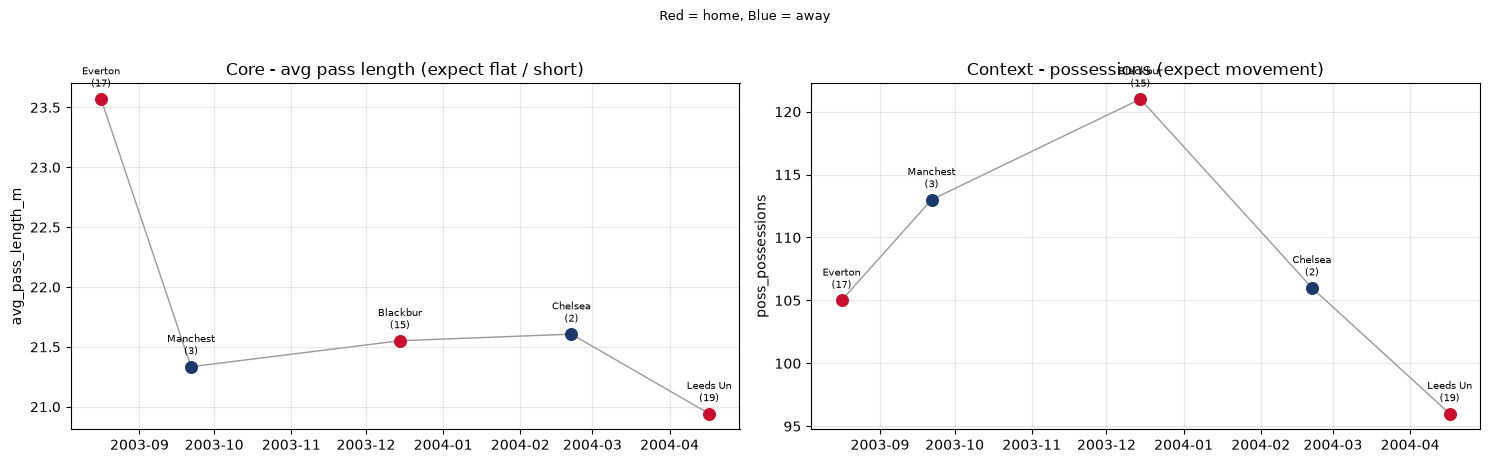

In [6]:
VENUE_COLOR = {"home": "#c8102e", "away": "#1b3a6b"}

def plot_metric_trajectory(df, metric, ax=None, title=None):
    """Style metric vs date; colour by venue, annotate opponent (final position)."""
    d = df.sort_values("date")
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4))
    ax.plot(d["date"], d[metric], color="0.6", lw=1, zorder=1)
    for _, r in d.iterrows():
        ax.scatter(r["date"], r[metric], s=70,
                   color=VENUE_COLOR.get(r["venue"], "0.4"), zorder=2)
        ax.annotate(f"{r['opponent'][:8]}\n({int(r['opp_final_position'])})",
                    (r["date"], r[metric]), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=7)
    ax.set(title=title or metric, ylabel=metric)
    ax.grid(alpha=0.3)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
plot_metric_trajectory(five, "avg_pass_length_m", axes[0],
                       "Core - avg pass length (expect flat / short)")
plot_metric_trajectory(five, "poss_possessions", axes[1],
                       "Context - possessions (expect movement)")
fig.suptitle("Red = home, Blue = away", fontsize=9, y=1.02)
fig.tight_layout()
plt.show()

<hr>

## Verdict - Phase 1

**Plumbing: PASS.** The Everton opener reproduces the case-study numbers (gate
assertion holds), all 5 rows are sane, rates behave even in the low-event
Blackburn grind, and there are no NaNs.

**Core identity is context-robust - the real validation win.** Across home/away
and weak/elite opponents the fingerprint barely moves: pass length stays short
(20.9-23.6 m), long-ball share low (18-24%), carries high (75-87 /100), build-up
deep (start-x 38-44), and the passing network stays dense (connectivity
~0.38-0.61, clustering 0.70-0.80). The directional-table core deltas are all
small - the pipeline is measuring an identity, not a home-comfort artifact.

**One expectation was refuted (a genuine mini-finding).** I predicted the context
traits (passes, possessions, completion) would *drop* in the contested away
games. Only **passes** did (-39). **Possessions actually rose** (107 -> 110) and
**completion was flat** (77.6 -> 77.9): away at Chelsea and - strikingly - 0-0 at
Old Trafford, Arsenal retained the ball as much as at home (Man Utd away: 113
possessions, 490 passes, 78.8% completion, 15 sustained 6+ chains). The
Invincibles' possession dominance was **not** venue/opponent-dependent here.
Caveat: only n=2 contested games — so before Phase 2 weighs it across 38, the
diagnostics below stress-test the claim against *all 135* features rather than the
handful we hand-picked.

**Next - deeper diagnostics.** This curated check looked only where we expected
identity to live (~15 of 135 features). The section below drops the hand-picking
and re-derives the core/context split systematically, then confirms it reproduces
the metrics we chose by hand. The date-keyed trajectory scaffolding still scales
directly to the full 38-match season in Phase 2.

---

**Bridge — Phase 1 → deeper diagnostics: from a curated check to a systematic scan**

Everything above tested the fingerprint on a *hand-picked* set of core/context
metrics — the hypothesis we walked in with. Its blind spot: we only looked where
we already expected identity to live, and only at ~15 of 135 engineered features.

The section below drops the hand-picking. It scans **all 135 features** and scores
each on the same two axes we just eyeballed — **stability** (Q1, low CV = "core")
and **opponent-response** (Q2, high Spearman = "context") — then adds robustness
(Q3) and redundancy (Q4) and sorts every feature into a tier. The vocabulary
carries straight over:

- `core` (stable identity) → **identity_anchor**
- `context` (game-state) → **context_lever**

This is the same claim tested at full scale, and it closes the loop back to
Phase 1 two ways:

1. **Do the hand-picked core metrics survive without being privileged?** If
   `avg_pass_length_m`, `carries_per100pass`, `poss_mean_start_x`, … fall out as
   low-CV anchors on their own, the intuition generalizes rather than being an
   artifact of which metrics we chose to plot.
2. **Does the directional-check anomaly hold up?** Phase 1 flagged that completion
   % and possessions *didn't* dip when contested. The scan corroborates it —
   `pass_completion_pct` turns out to be the lowest-CV *non-degenerate* feature in
   the set (CV 0.014), tiered `identity_anchor`, not a context lever. The
   **loop-back cell at the end of Q4** makes this comparison explicit in code.

<hr>

# Deeper diagnostics (Q1-Q4)

Extends the validation into feature-level statistics that will be **re-run at
n=38 (Phase 2)** and full-league (Phase 3) - every function below takes
`(df, chains)` so it scales unchanged. All 5-match conclusions here are
**provisional**.

**Two honesty guardrails, restated:**
- **Venue and opponent-strength are collinear** in these 5 picks (both away games
  are the two elite sides). "Opponent response" below = response in *contested*
  (away+elite) games; venue vs opponent can't be separated until Phase 2.
- **n=5** makes aggregate CVs, Spearman and correlations unstable. Real
  statistical weight comes from the **chain level** (hundreds of Arsenal chains),
  where we report effect sizes rather than p-values (within-match chains aren't
  independent).

Every feature is scored on two axes - **dispersion (CV)** and **opponent
association** - and the (CV x association) map answers all four questions.

In [7]:
from scipy.stats import spearmanr, mannwhitneyu

# Context / id / outcome / string columns are not style features.
DROP = {
    "season", "match_id", "date", "match_week", "team", "opponent", "venue",
    "result", "goals_for", "goals_against", "goals", "opp_final_points",
    "opp_final_position", "red_cards_for", "red_cards_against",
    "pi_top_player_name", "pi_top_edge",
}
feat_cols = [c for c in five.columns
             if c not in DROP and pd.api.types.is_numeric_dtype(five[c])]
print(f"numeric engineered features scanned: {len(feat_cols)}")

# chain-level table for these 5 matches (Arsenal possessions)
chains = pd.read_parquet(FEATURES_DIR / "possession_chains.parquet")
ars_ch = chains[(chains["match_id"].isin(order)) &
                (chains["possession_team"] == "Arsenal")].copy()
ars_ch["label"] = ars_ch["match_id"].map(labels)
ars_ch["group"] = np.where(ars_ch["label"].isin(CONTESTED), "contested", "dominant")
print("Arsenal chains per match:")
print(ars_ch["label"].value_counts().reindex([l for _, l in TARGETS]).to_string())

numeric engineered features scanned: 135
Arsenal chains per match:
label
Everton (H) 2-1      105
Leeds (H) 5-0         96
Chelsea (A) 2-1      106
Man Utd (A) 0-0      113
Blackburn (H) 1-0    121


<hr>

## Q1 - Which tactical characteristics remain stable?

> **Guiding question:** across the 5 matches, which features barely move — the
> candidate *identity* traits — and which swing the most? *(Answered by the CV table
> and heat map below.)*

Dispersion across the 5 matches via **coefficient of variation** (CV = $\frac{\sigma}{| \mu |}$).
Low CV = stable = identity. (Watch for *degenerate* stability - a feature constant
at 0 has CV~0 but carries no information; flagged in Q3.)

In [8]:
def dispersion_scan(df, cols):
    d = df[cols]
    s = pd.DataFrame({"mean": d.mean(), "std": d.std(ddof=1),
                      "min": d.min(), "max": d.max()})
    s["range"] = s["max"] - s["min"]
    s["cv"] = (s["std"] / s["mean"].abs()).replace([np.inf, -np.inf], np.nan)
    return s.sort_values("cv")

disp = dispersion_scan(five, feat_cols)
print("=== Most STABLE (low CV) ===")
print(disp.head(5)[["mean", "std", "cv"]].round(3).to_string())
print("\n=== Most VARIABLE (high CV) ===")
print(disp.dropna(subset=["cv"]).tail(5)[["mean", "std", "cv"]].round(3).to_string())

=== Most STABLE (low CV) ===
                                 mean    std     cv
rhythm_median_gap_sec           1.000  0.000  0.000
pass_completion_pct            77.747  1.093  0.014
pi_angle_entropy                2.827  0.063  0.022
pi_pass_progression_share_pct  73.671  2.018  0.027
rhythm_mean_burst_share        71.213  2.357  0.033

=== Most VARIABLE (high CV) ===
                                    mean     std     cv
through_balls_per100pass           0.478   0.506  1.059
through_balls                      2.400   2.702  1.126
rp6_total_xg                       0.195   0.285  1.462
rhythm_median_pre_prog_passes      0.300   0.447  1.491
rhythm_median_pre_prog_pass_share  9.524  14.677  1.541


**The stable floor is the passing machinery; the volatile top is rare-event
output.** The lowest-CV features are the build-up mechanics — `pass_completion_pct`
(CV 0.014), `pi_angle_entropy` (0.022), `pi_pass_progression_share_pct` (0.027),
`rhythm_mean_burst_share` (0.033): how Arsenal pass barely moves across the five
games. (`rhythm_median_gap_sec` sits at CV 0.000 only because it's constant at 1.0
— a *degenerate* feature Q3 flags, not a real anchor.) The highest-CV features are
all small-count events — `through_balls` (CV 1.13), `rp6_total_xg` (1.46), the two
`rhythm_median_pre_prog_*` (~1.5). But high CV here mostly reflects near-zero means
(through-balls average 0.48 a match), so the ratio explodes — that's fragility, not
opponent-response. Separating "genuinely context-driven" from "just a rare count"
is exactly why Q2/Q4 tier on Spearman vs opponent strength, not on CV.

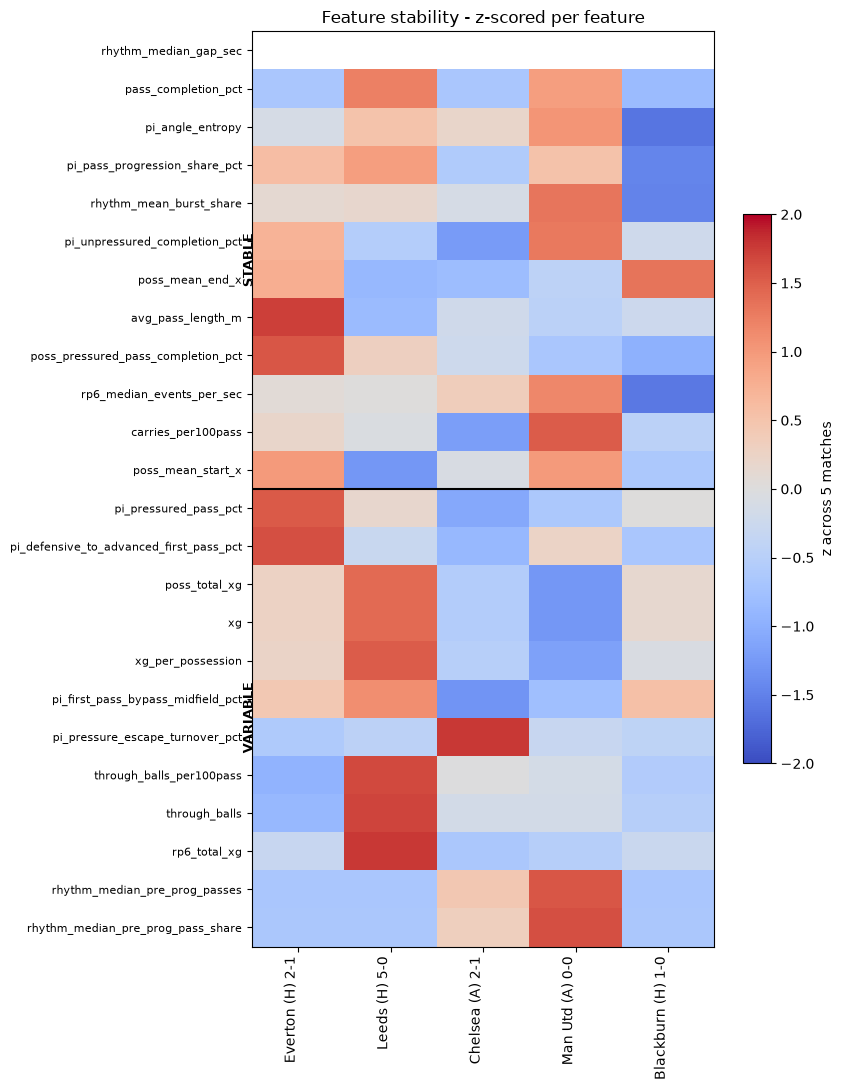

In [9]:
# z-scored PER FEATURE (per row): colour shows each match's relative high/low for
# that row, NOT magnitude of variation (that's the CV table - every non-degenerate
# row is stretched to unit spread here). STABLE/VARIABLE split is by CV rank (the
# divider line), not by colour.
sel = list(disp.head(12).index) + list(disp.dropna(subset=["cv"]).tail(12).index)
Z = five.set_index("label")[sel].T
Z = Z.sub(Z.mean(axis=1), axis=0).div(Z.std(axis=1, ddof=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(figsize=(8.5, 11))
im = ax.imshow(Z.values, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(range(Z.shape[1])); ax.set_xticklabels(Z.columns, rotation=90, ha="right")
ax.set_yticks(range(Z.shape[0])); ax.set_yticklabels(Z.index, fontsize=8)
ax.axhline(11.5, color="k", lw=1.5)
ax.text(-0.6, 5.5, "STABLE", rotation=90, va="center", fontweight="bold", fontsize=9)
ax.text(-0.6, 17.5, "VARIABLE", rotation=90, va="center", fontweight="bold", fontsize=9)
fig.colorbar(im, ax=ax, label="z across 5 matches", shrink=0.6)
ax.set_title("Feature stability - z-scored per feature")
plt.tight_layout(); plt.show()

From the heat map there's no single trend running through either the *stable* or
the *variable* block — and that's expected, since most of what moves here is
context-dependent output, not identity. Two things to keep in mind when reading it:

- **Colour = pattern, not magnitude.** Each row is z-scored on its own across the
  5 matches, so every feature is stretched to the same spread — even
  `pass_completion_pct` (the most stable feature in the whole set, CV 0.01) shows
  strong reds and blues. So don't read stability off the colour; that's the CV
  table's job. What the colour shows is *which match sits high or low for each
  feature*, and the STABLE/VARIABLE split comes from the CV rank (the divider
  line), not the colour.
- **Read it per column (per match), not per row.** A red cell means that match runs
  high on that feature relative to the other four.

**Leeds (5-0) is the clear outlier — exactly where it should be.** The blowout
lights up the attacking-output cluster in the variable block: xG and
xG-per-possession (z ≈ +1.5), through-balls (+1.7) and midfield-bypassing first
passes (+1.1). Total dominance surfaces as *output and directness*, not as any
change in the core mechanics above the divider — which is the whole point: the
identity held while the scoreboard ran away.

**The four tight games (≤1-goal margin) cluster rather than trend.** On that same
output cluster Everton, Chelsea, Man Utd and Blackburn all sit muted (xG z between
−1.3 and +0.25) — the quiet baseline Leeds stands out against. They don't line up
along a single gradient (the x-axis isn't an ordered axis anyway); instead each
peaks on a *different* dimension: Everton on longer passes and pressed-pass share,
Man Utd — the hardest game, 0-0 at Old Trafford — on the control/identity block
(completion, patient pre-progression build-up, carries), and Blackburn muted almost
everywhere (the low-event grind; lowest mean |z| of the five). So the signal is
**Leeds-as-outlier plus a tight-match cluster**, not a smooth trend across the five.

<hr>

## Q2 - Which characteristics change with opponent?

> **Guiding question:** which features track *opponent strength* — moving
> systematically as Arsenal go from weaker sides to elite ones — and in which
> direction? *(Answered by the responsiveness table below, and stress-tested on real
> n at the chain level.)*

Two indicators per feature: the **standardized contrast** between contested and
dominant groups (`delta / feature_std`), and **Spearman** vs `opp_final_position`
(lower position = stronger side). Both are fragile at n=5 - read as ranking, not
proof. Reminder: contested = away+elite, so this blends venue and opponent.

In [10]:
def opponent_response(df, cols, dominant, contested):
    g = df.set_index("label")
    out = {}
    for c in cols:
        sd = g[c].std(ddof=1)
        delta = g.loc[contested, c].mean() - g.loc[dominant, c].mean()
        std_delta = delta / sd if sd and not np.isnan(sd) else np.nan
        rho = spearmanr(df[c], df["opp_final_position"])[0] if df[c].nunique() > 1 else np.nan
        out[c] = {"std_delta_contested_minus_dom": std_delta, "spearman_vs_opp_pos": rho}
    r = pd.DataFrame(out).T
    r["abs_assoc"] = r[["std_delta_contested_minus_dom", "spearman_vs_opp_pos"]].abs().max(axis=1)
    return r

resp = opponent_response(five, feat_cols, DOMINANT, CONTESTED)
print("=== Most opponent-RESPONSIVE features ===")
print(resp.sort_values("abs_assoc", ascending=False).head(15).round(3).to_string())

=== Most opponent-RESPONSIVE features ===
                                    std_delta_contested_minus_dom  spearman_vs_opp_pos  abs_assoc
poss_ends_box_pct                                          -1.793                0.600      1.793
poss_box_entry_pct                                         -1.789                0.900      1.789
pi_unpressured_mean_dx                                     -1.782                0.500      1.782
pi_first_pass_bypass_midfield_pct                          -1.733                0.900      1.733
dribbles                                                   -1.730                0.975      1.730
fouls_committed_per100pass                                  1.705               -1.000      1.705
rhythm_median_pre_prog_passes                               1.677               -0.783      1.677
pi_progression_per_pass                                    -1.660                0.500      1.660
rhythm_mean_avg_progressive_x_gain                         -1.645           

**The movers are territory and progression, not core mechanics.** In the contested
(away+elite) games Arsenal enter the box less (`poss_box_entry_pct`,
`poss_ends_box_pct`), progress the ball less far (`poss_median_net_x`, progressive
x-gain), bypass midfield less, and dribble/shoot less. What *rises* is patience and
friction — more passes before advancing (`rhythm_median_pre_prog_*`) and more fouls
committed. So a stronger opponent doesn't change *how* Arsenal build; it compresses
*how far that build travels*. (Negative std_delta / positive Spearman = lower vs
stronger sides. Still n=5 with away≡elite, so read as a ranking, not proof — per
the caveat above.)

## Q1/Q2 at the chain level (real n)

The aggregate rows are n=5; here each Arsenal **possession chain** is a data point
(Regular Play only, to match the buildup-identity framing). If a chain-metric
*distribution* barely shifts across opponents, that trait is genuinely stable;
if it separates dominant vs contested, that trait is opponent-sensitive.
Effect size = **rank-biserial** (from Mann-Whitney); p-values muted because
within-match chains are correlated.

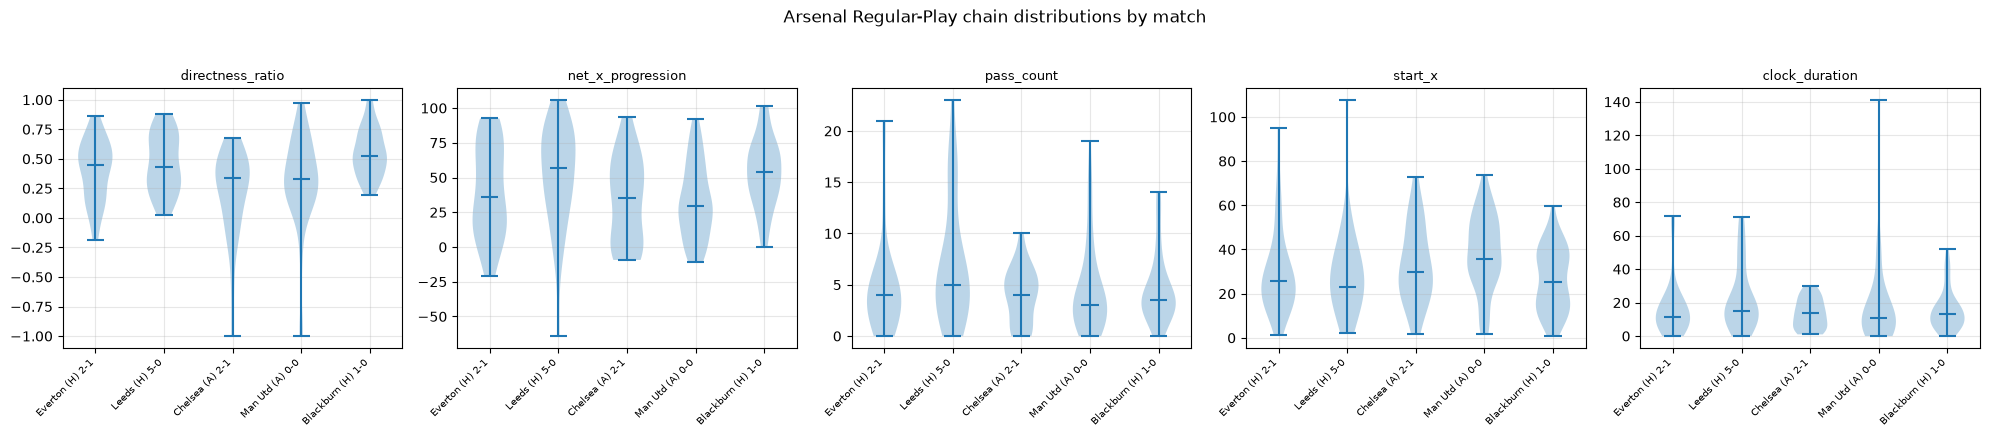

In [11]:
rp = ars_ch[ars_ch["play_pattern"] == "Regular Play"].copy()
CHAIN_METRICS = ["directness_ratio", "net_x_progression", "pass_count",
                 "start_x", "clock_duration"]
order_labels = [l for _, l in TARGETS]

fig, axes = plt.subplots(1, len(CHAIN_METRICS), figsize=(20, 4.2))
for ax, m in zip(axes, CHAIN_METRICS):
    data = [rp[rp["label"] == l][m].dropna().values for l in order_labels]
    ax.violinplot(data, showmedians=True)
    ax.set_xticks(range(1, len(order_labels) + 1))
    ax.set_xticklabels(order_labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(m, fontsize=9); ax.grid(alpha=0.3)
fig.suptitle("Arsenal Regular-Play chain distributions by match", y=1.03)
plt.tight_layout(); plt.show()

In [12]:
def chain_effects(df, metrics):
    rows = []
    for m in metrics:
        a = df[df["group"] == "dominant"][m].dropna()
        b = df[df["group"] == "contested"][m].dropna()
        if len(a) == 0 or len(b) == 0:
            continue
        u = mannwhitneyu(a, b, alternative="two-sided")[0]
        rbc = 1 - 2 * u / (len(a) * len(b))   # rank-biserial effect size, [-1, 1]
        rows.append({"metric": m, "dom_median": a.median(), "con_median": b.median(),
                     "rank_biserial": rbc, "n_dom": len(a), "n_con": len(b)})
    return pd.DataFrame(rows).set_index("metric")

print(chain_effects(rp, CHAIN_METRICS).round(3).to_string())
print("\n(effect sizes only; within-match chains correlated -> directional, not inferential)")

                   dom_median  con_median  rank_biserial  n_dom  n_con
metric                                                                
directness_ratio        0.479       0.338         -0.333    113     83
net_x_progression      49.000      30.800         -0.304    115     85
pass_count              4.000       4.000         -0.099    118     85
start_x                25.200      35.200          0.318    115     85
clock_duration         13.500      11.000         -0.113    118     85

(effect sizes only; within-match chains correlated -> directional, not inferential)


**Real-n confirmation: the build-up unit is fixed, the output flexes.** With each
chain as a data point, `pass_count` is *identical* across groups (median 4, rbc
−0.10) — the passing sequence itself doesn't change. What moves is downstream and
moderate: when contested the chains are less direct (0.48 → 0.34, rbc −0.33) and
progress less far (net-x 49 → 31, rbc −0.30), while starting ~10 m higher up the
pitch (start-x 25 → 35, rbc +0.32) — Arsenal regain the ball higher but carry it
less far against elite sides. Same story as the aggregate Q2, now on hundreds of
chains rather than 5 rows. The violin plot shows it visually: the `pass_count`
distributions overlap across all five matches, while `directness_ratio` and
`net_x_progression` shift down for Chelsea and Man Utd.

<hr>

## Q3 - Which engineered features appear robust?

> **Guiding question:** can we actually *trust* the "stable" features Q1 surfaced —
> or is some of that stability fake, either a degenerate column (constant / all-zero)
> or a number driven almost entirely by a single match? *(Answered in the cells below.)*

Per-feature diagnostics: missingness, **degeneracy** (constant / all-zero =
stable-but-useless), and **single-match dominance** (>60% of the feature's total
magnitude coming from one of the 5 matches = fragile/outlier-driven).

In [13]:
def robustness_flags(df, cols):
    d = df[cols]
    out = {}
    for c in cols:
        s = d[c]
        tot = s.abs().sum()
        out[c] = {"missing_frac": s.isna().mean(),
                  "constant": s.nunique(dropna=True) <= 1,
                  "max_row_share": (s.abs().max() / tot) if tot > 0 else np.nan,
                  "mean_abs": s.abs().mean()}
    r = pd.DataFrame(out).T
    r["degenerate"] = r["constant"].astype(bool) | (r["mean_abs"] == 0)
    r["one_match_driven"] = r["max_row_share"] > 0.6
    return r

rob = robustness_flags(five, feat_cols)
print("degenerate / constant:", list(rob[rob["degenerate"]].index) or "none")
print("\none-match-driven (>60% magnitude from a single match):")
print(rob[rob["one_match_driven"]].sort_values("max_row_share", ascending=False)
      .head(15)[["max_row_share"]].round(3).to_string() or "none")

degenerate / constant: ['pi_pressure_escape_forward_pass_pct', 'pi_pressure_escape_positive_carry_pct', 'rhythm_median_gap_sec']

one-match-driven (>60% magnitude from a single match):
                                  max_row_share
rp6_total_xg                           0.716586
rhythm_median_pre_prog_pass_share           0.7
rhythm_median_pre_prog_passes          0.666667


**Almost everything is well-behaved; the fragile handful is either constant or
one-match-driven.** Only 3 features are degenerate — two `pi_pressure_escape_*`
(all-zero across these 5) and `rhythm_median_gap_sec` (constant 1.0) — and 3 are
one-match-driven (>60% of their magnitude from a single game): `rp6_total_xg` (72%,
almost all Leeds) and the two `rhythm_median_pre_prog_*`. Note these two flags feed
the registry differently: it ends up dropping **5** as `drop_noisy` — the 3
degenerate plus the 2 low-association pre-progression rhythms — while `rp6_total_xg`
*survives* as a `context_lever`, because even though it's Leeds-driven its spike
still ranks with opponent strength (|Spearman| high). At n=5, "one-match-driven" is
unavoidable for any rare event, so treat these as watch-flags to re-check at n=38,
not verdicts.

<hr>

## Q4 - Redundancy (provisional at n=5)

> **Guiding question:** do these features duplicate each other — and, pulling Q1-Q3
> together, which do we keep for the full season: as identity, as a control, or drop
> entirely? *(Answered across the redundancy check, the tier registry and the feature
> map below.)*

Highly collinear features are duplicate carriers of information; for scaling we'd
keep one per cluster. **At n=5 correlations are wildly unstable** - this pass is
illustrative, not a pruning decision. Real redundancy analysis runs at n=38.

394 feature pairs with |r|>0.90 at n=5 (PROVISIONAL - expect heavy spurious collinearity this small)


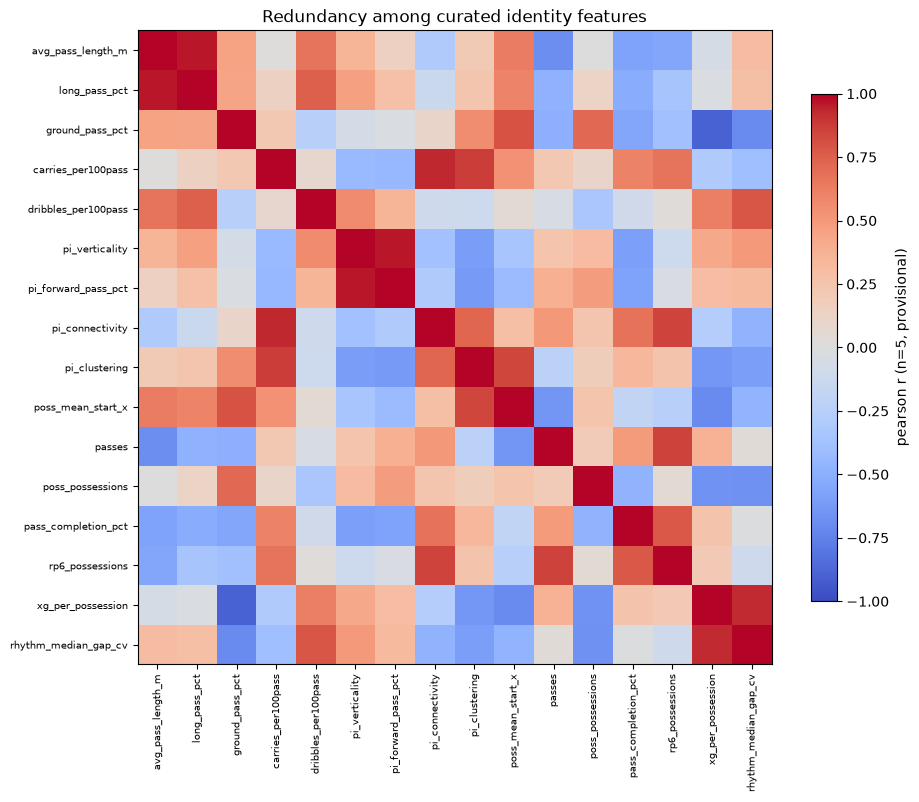

In [15]:
import itertools
corr = five[feat_cols].corr()
hi = [(a, b, round(corr.loc[a, b], 3))
      for a, b in itertools.combinations(feat_cols, 2)
      if abs(corr.loc[a, b]) > 0.9]
print(f"{len(hi)} feature pairs with |r|>0.90 at n=5 (PROVISIONAL - "
      f"expect heavy spurious collinearity this small)")

sub = list(dict.fromkeys([c for c, _ in CORE] + [c for c, _ in CONTEXT]))
cm = five[sub].corr()
fig, ax = plt.subplots(figsize=(9.5, 8.5))
im = ax.imshow(cm.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(sub))); ax.set_xticklabels(sub, rotation=90, fontsize=7)
ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub, fontsize=7)
fig.colorbar(im, ax=ax, label="pearson r (n=5, provisional)", shrink=0.7)
ax.set_title("Redundancy among curated identity features")
plt.tight_layout(); plt.show()

**394 collinear pairs is an artefact of n=5, not real redundancy.** With only 5
points, almost any two features line up by chance, so `|r|>0.90` on 394 of them is
close to meaningless — it says more about the sample size than about the features.
The heatmap over the curated identity set is suggestive of genuine clusters (the
pass-length / carry / start-x build-up block reds together), but at this n it can't
justify dropping anything. Redundancy pruning — keep one feature per correlated
cluster — is deferred to n=38, where correlations finally have the degrees of
freedom to mean something.

### Feature-tier registry + feature map

Synthesis of Q1-Q3 into a provisional tier per feature. Association is measured
by **|Spearman vs opponent strength|** (scale-free) - the standardized delta is
kept for reference but *not* used to tier, since it is inflated for low-variance
features.
- **identity_anchor** - low CV, weak rank-association (the tactical DNA)
- **context_lever** - strong rank-association with opponent strength (control for in Phase 2)
- **drop_noisy** - degenerate, or one-match-driven without opponent structure
- **review** - everything else (resolve at n=38)

The **feature map** (CV x association) is the visual answer to all four questions.

In [33]:
# Tier on |Spearman vs opponent strength| (scale-free) rather than the
# standardized delta, which is variance-inflated (delta/std explodes when std is
# tiny, mislabelling stable features as "responsive").
reg = pd.DataFrame(index=feat_cols)
reg["cv"] = disp["cv"]
reg["std_delta"] = resp["std_delta_contested_minus_dom"]
reg["abs_spearman"] = resp["spearman_vs_opp_pos"].abs()
reg["degenerate"] = rob["degenerate"]
reg["one_match_driven"] = rob["one_match_driven"]

cv_lo = reg["cv"].median()
SPEAR_HI = 0.8   # strong rank association with opponent strength

def tier(r):
    if r["degenerate"]:
        return "drop_noisy"
    if r["one_match_driven"] and r["abs_spearman"] < SPEAR_HI:
        return "drop_noisy"
    if r["cv"] <= cv_lo and r["abs_spearman"] < SPEAR_HI:
        return "identity_anchor"
    if r["abs_spearman"] >= SPEAR_HI:
        return "context_lever"
    return "review"

reg["tier"] = reg.apply(tier, axis=1)
print("tier counts:"); print(reg["tier"].value_counts().to_string())
print("\nidentity anchors (most stable):",
      list(reg[reg.tier == "identity_anchor"].sort_values("cv").index[:12]))
print("\ncontext levers (strongest rank-assoc):",
      list(reg[reg.tier == "context_lever"].sort_values("abs_spearman", ascending=False).index[:12]))
reg.sort_values(["tier", "cv"]).round(3)

tier counts:
tier
identity_anchor    56
review             51
context_lever      23
drop_noisy          5

identity anchors (most stable): ['pass_completion_pct', 'pi_angle_entropy', 'pi_pass_progression_share_pct', 'rhythm_mean_burst_share', 'pi_unpressured_completion_pct', 'poss_mean_end_x', 'avg_pass_length_m', 'poss_pressured_pass_completion_pct', 'rp6_median_events_per_sec', 'carries_per100pass', 'poss_mean_start_x', 'pi_clustering']

context levers (strongest rank-assoc): ['fouls_committed_per100pass', 'pi_centralization', 'dribbles', 'pi_network_players', 'dribbles_complete', 'pi_pressure_escape_turnover_pct', 'dribbles_per100pass', 'rhythm_mean_avg_progressive_x_gain', 'rhythm_median_gap_cv', 'rp6_total_xg', 'poss_total_xg', 'poss_box_entry_pct']


,cv,std_delta,abs_spearman,degenerate,one_match_driven,tier
rhythm_median_gap_cv,0.058,-1.434,0.900,False,False,context_lever
pi_early_width_y_std,0.063,1.499,0.900,False,False,context_lever
pi_network_players,0.065,-1.594,0.949,False,False,context_lever
rhythm_mean_avg_progressive_x_gain,0.066,-1.645,0.900,False,False,context_lever
rp6_box_entry_pct,0.073,-1.483,0.872,False,False,context_lever
...,...,...,...,...,...,...
pressure_on_pass_pct,0.431,-1.287,0.700,False,False,review
crosses,0.443,-1.009,0.359,False,False,review
pi_defensive_to_advanced_first_pass_pct,0.513,-0.543,0.500,False,False,review
through_balls_per100pass,1.059,-0.121,0.000,False,False,review


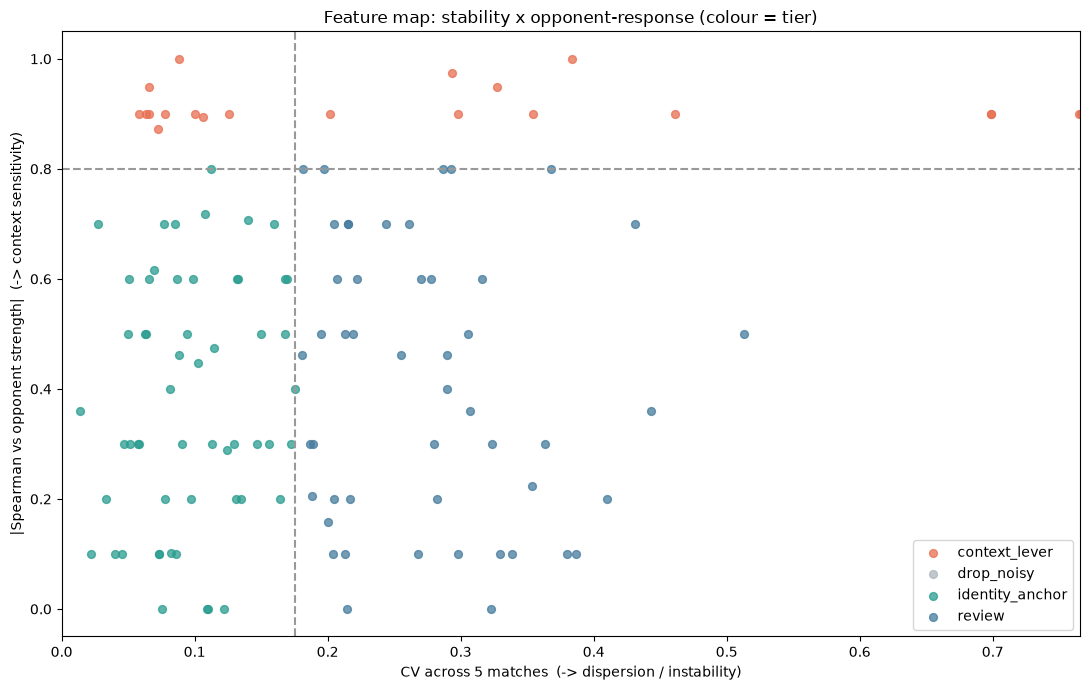

In [17]:
TIER_COLOR = {"identity_anchor": "#2a9d8f", "context_lever": "#e76f51",
              "drop_noisy": "#adb5bd", "review": "#457b9d"}
fig, ax = plt.subplots(figsize=(11, 7))
for t, grp in reg.groupby("tier"):
    ax.scatter(grp["cv"], grp["abs_spearman"], s=32, alpha=0.75,
               color=TIER_COLOR.get(t, "k"), label=t)
ax.axvline(cv_lo, ls="--", c="0.6"); ax.axhline(SPEAR_HI, ls="--", c="0.6")
ax.set_xlim(0, reg["cv"].quantile(0.95))
ax.set_xlabel("CV across 5 matches  (-> dispersion / instability)")
ax.set_ylabel("|Spearman vs opponent strength|  (-> context sensitivity)")
ax.set_title("Feature map: stability x opponent-response (colour = tier)")
ax.legend(); plt.tight_layout(); plt.show()

**The 135 features sort into 56 `identity_anchor` / 23 `context_lever` / 51
`review` / 5 `drop_noisy`.** The anchors are the fingerprint again — the most
stable are `pass_completion_pct`, `avg_pass_length_m`, `carries_per100pass`,
build-from-the-back `poss_mean_start_x`, `pi_clustering` — sitting bottom-left of
the map (low CV *and* low opponent-association). The levers are territory, pressure
and 1v1 volume — `poss_box_entry_pct`, `dribbles`, `fouls_committed_per100pass`,
`poss_total_xg` — up top at high |Spearman|. The two axes aren't the same question:
**CV** asks *does the number move?* while **Spearman** asks *does its movement rank
with opponent strength?* That gap is why a barely-moving feature like
`pi_network_players` (CV 0.065) still lands as a lever — its small movement tracks
opponent strength almost perfectly (|Spearman| 0.95) — and why tiering on Spearman
beats the variance-inflated standardized delta. The `review` band (51, the
unresolved middle) and the redundancy prune both wait for n=38; for Phase 2 we
retain both anchors (the identity signal) and levers (the controls in
`metric ~ date + venue + opp_strength`).

<hr>

## Loop-back - does the systematic tiering reproduce the Phase 1 hand-picks?

The registry was built with no knowledge of the curated `CORE` / `CONTEXT` lists.
If the diagnostics are sound, the hand-picked **core** metrics should land in
`identity_anchor` and the **context** metrics in `context_lever`. Agreement means
the systematic scan *re-derives* the fingerprint we walked in with — earning the
right to extend the method to the ~120 features we never inspected by hand.
Disagreements are equally useful: they flag exactly the metrics Phase 1 mislabeled
— above all the completion-% / possessions anomaly the directional check surfaced,
which reappears here as a low-CV `identity_anchor` rather than a context lever.

In [18]:
# Loop back to Phase 1: the registry above was built with NO knowledge of the
# curated CORE / CONTEXT lists. Do the hand-picked metrics land in the tier their
# Phase 1 label predicts?  core -> identity_anchor, context -> context_lever.
EXPECT_TIER = {"core": "identity_anchor", "context": "context_lever"}
hand = [(c, "core") for c, _ in CORE] + [(c, "context") for c, _ in CONTEXT]

loopback = pd.DataFrame(
    [{"metric": c, "phase1_label": lab,
      "cv": reg.loc[c, "cv"], "abs_spearman": reg.loc[c, "abs_spearman"],
      "data_tier": reg.loc[c, "tier"],
      "agrees": reg.loc[c, "tier"] == EXPECT_TIER[lab]}
     for c, lab in hand if c in reg.index]
).set_index("metric")

print("hand-picked -> data-driven tier agreement:")
print(loopback.groupby("phase1_label")["agrees"].mean().round(2).to_string())
print(f"\noverall: {loopback['agrees'].mean():.0%} of hand-picked metrics land in "
      "the tier their Phase 1 label predicts")
print("\ndisagreements (where the systematic scan overturns the hand label):")
dis = loopback[~loopback["agrees"]]
print(dis[["phase1_label", "data_tier", "cv", "abs_spearman"]].round(3).to_string()
      if len(dis) else "  none")
loopback.round(3)

hand-picked -> data-driven tier agreement:
phase1_label
context    0.33
core       0.80

overall: 62% of hand-picked metrics land in the tier their Phase 1 label predicts

disagreements (where the systematic scan overturns the hand label):
                    phase1_label        data_tier     cv  abs_spearman
metric                                                                
dribbles_per100pass         core    context_lever  0.298         0.900
pi_verticality              core           review  0.213         0.500
passes                   context  identity_anchor  0.114         0.474
poss_possessions         context  identity_anchor  0.087         0.600
pass_completion_pct      context  identity_anchor  0.014         0.359
rp6_possessions          context           review  0.255         0.462


,phase1_label,cv,abs_spearman,data_tier,agrees
metric,,,,,
avg_pass_length_m,core,0.047,0.300,identity_anchor,True
long_pass_pct,core,0.122,0.000,identity_anchor,True
ground_pass_pct,core,0.113,0.300,identity_anchor,True
carries_per100pass,core,0.051,0.300,identity_anchor,True
dribbles_per100pass,core,0.298,0.900,context_lever,False
pi_verticality,core,0.213,0.500,review,False
pi_forward_pass_pct,core,0.063,0.500,identity_anchor,True
pi_connectivity,core,0.172,0.300,identity_anchor,True
pi_clustering,core,0.058,0.300,identity_anchor,True


<hr>

## Synthesis (Q1-Q4)

**Q1 - Stable characteristics (the identity).** The lowest-CV features are exactly
the Wenger fingerprint: pass completion (CV 0.01), average pass length (0.05),
carries /100 passes (0.05), build-from-the-back start-x (0.06), network clustering
(0.06), forward-pass share (0.06), angle entropy and pass-progression share.
Chain-level confirms it - **passes-per-chain is identical** across every opponent
(median 4 in both groups; effect ~ -0.10). These hold across home/away and
weak/elite: the tactical DNA.

**Q2 - Characteristics that change (contested = away+elite).** The movers are
**territory, progression and 1v1 volume**, not core mechanics: box-entry %,
per-chain directness and net-x progression, dribbles, turnovers, xG. Chain-level
effect sizes (the trustworthy signal) show that in contested games Arsenal's
chains are **less direct** (median 0.48 -> 0.34, rbc -0.33), **progress less far**
(net-x 49 -> 31, rbc -0.30) and **start ~10 m higher** (start-x 25 -> 35, rbc
+0.32) - all moderate. So *what* Arsenal do (short, deep, carry-led build-up) is
fixed; *how far it travels and where it starts* flex with the opponent.

**Q3 - Robust engineered features.** 129/135 behave well. Flagged fragile:
**3 degenerate** (constant / all-zero: two `pi_pressure_escape_*` and
`rhythm_median_gap_sec`=1.0) and **3 one-match-driven** (`rp6_total_xg`,
`rhythm_median_pre_prog_passes`/`_pass_share`). The registry ultimately drops
**5 as `drop_noisy`** - the 3 degenerate plus the 2 low-association pre-progression
rhythms; `rp6_total_xg` survives as a `context_lever` (its Leeds spike still ranks
with opponent strength). Also inherently noisy at match scale - rare-event counts
(`through_balls`, per-match xG) with CV > 0.7. Low per-match signal.

**Q4 - Retain for season-wide scaling.** Provisional registry over 135 features:
**56 identity_anchor, 23 context_lever, 51 review, 5 drop_noisy**. Retain both
anchors (identity signal) and levers (required controls in Phase 2's
`metric ~ date + venue + opp_strength`); drop the degenerate + rare-event noise;
resolve `review` at n=38.

**Honest limits (why this is provisional):**
1. **n=5** - aggregate CV/Spearman are indicative rankings, not estimates. Tiering
   uses scale-free Spearman (not the variance-inflated standardized delta), but
   the boundaries are still soft.
2. **Venue and opponent are collinear** here (both away games are the elite ones),
   so every "opponent" effect above is really an away+elite effect until Phase 2.
3. **394 feature pairs exceed |r|>0.9** - almost all spurious at n=5. Redundancy
   pruning is deferred to n=38.

**Bottom line:** the pipeline cleanly separates a stable Arsenal identity from
opponent-driven territory/progression, and the diagnostic machinery (dispersion,
association, chain distributions, robustness, tier registry) is built to re-run
unchanged at n=38, where these answers become real.